In [1]:
import pandas as pd

# # Load the DataFrames
# df = pd.read_csv('results/bay_area_properties_w_kid_friendly_score_bay_area.csv')
# coolness_df = pd.read_csv('data/Coolness_Score.csv')

# # Merge on mismatched column names: 'city' (df) and 'City' (coolness_df)
# merged_df = pd.merge(df, coolness_df, left_on='city', right_on='City', how='left')

# # Drop redundant/unwanted columns from coolness_df
# merged_df.drop(columns=['City', 'County'], inplace=True)

# print(merged_df.shape)
# merged_df.head()

# merged_df.to_csv('results/bay_area_properties_kid_friendly_score_cool_score.csv', index=False)


In [3]:
## run 03/23/2026

"""
COMPLETE BAY AREA REAL ESTATE ML PIPELINE
==========================================
Comprehensive prediction system for property prices and types
Run: python complete_ml_pipeline.py
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             classification_report, accuracy_score)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              RandomForestClassifier)
import xgboost as xgb

print("=" * 80)
print("BAY AREA REAL ESTATE - COMPLETE ML PIPELINE")
print("=" * 80)
print("\nObjectives:")
print("  1. Predict property types (Classification)")
print("  2. Predict sale prices (Regression)")
print("  3. Affordability analysis")
print("  4. Interactive recommendations")
print("=" * 80)

# ══════════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ══════════════════════════════════════════════════════════════════
# DATA_FILE = './bay_area_properties_WITH_SCHOOLS.xlsx'

# merged_df.to_csv('results/bay_area_properties_kid_friendly_score_cool_score.csv', index=False)

DATA_FILE = ('results/bay_area_properties_kid_friendly_score_cool_score.csv')
if not os.path.exists(DATA_FILE):
    print("\nERROR: Data file not found!")
    print("Please run: python generate_bay_area_properties.py first")
    exit(1)

print("\n[1/7] LOADING DATA...")
df = pd.read_csv(DATA_FILE)
print(f"  Loaded {len(df):,} properties")
print(f"  Columns: {len(df.columns)}")
print(f"  Date range: {df['sale_date'].min()} to {df['sale_date'].max()}")

# ══════════════════════════════════════════════════════════════════
# 2. FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════
print("\n[2/7] FEATURE ENGINEERING...")

df['sale_date'] = pd.to_datetime(df['sale_date'])
df['sale_year'] = df['sale_date'].dt.year
df['sale_month'] = df['sale_date'].dt.month
df['sale_quarter'] = df['sale_date'].dt.quarter
df['property_age'] = 2026 - df['year_built']
df['is_new_construction'] = (df['property_age'] <= 5).astype(int)
df['bath_bed_ratio'] = df['bathrooms'] / (df['bedrooms'] + 1)
df['sqft_per_bedroom'] = df['sqft'] / (df['bedrooms'] + 1)
df['amenity_score'] = df['pool'] + df['fireplace'] + df['parking_spaces']
df['coolness_index'] = df['coolness_index']
df['kid_friendly_score'] = df['kid_friendly_score']
df['has_hoa'] = (df['hoa_fee'] > 0).astype(int)
df['is_single_family'] = (df['property_type'] == 'Single Family').astype(int)
df_zip_code_avg_sale_price = df.groupby('zip_code')['sale_price'].mean().reset_index().rename({'sale_price': 'avg_zip_code_sale_price'}, axis=1)
df_city_avg_sale_price = df.groupby('city')['sale_price'].mean().reset_index().rename({'sale_price': 'avg_city_sale_price'}, axis=1)
df = df.merge(df_zip_code_avg_sale_price, on='zip_code').merge(df_city_avg_sale_price, on='city')

print(f"  Created 11 new features")
print(f"  Total columns: {len(df.columns)}")

# ══════════════════════════════════════════════════════════════════
# 3. PREPARE ML DATA
# ══════════════════════════════════════════════════════════════════
print("\n[3/7] PREPARING ML DATA...")

# --- FIX: drop datetime, ID, target-leak, and geo columns BEFORE encoding ---
DROP_COLS = [
    'property_id',         # ID — not a feature
    'sale_date',           # datetime — already extracted year/month/quarter
    'sale_price',          # regression target
    'latitude', 'longitude', #  no need to add to model 
    'year_built',          # replaced by property_age
    'zip_code',            # high cardinality, already have city/county
    'is_single_family',    # classification target
    'price_per_sqft',      # derived from sale_price — TARGET LEAKAGE
    'price_per_sqft_log',  # same leakage
    'n_parks', # same to kid friendly score
    'Attractions',
    'Restaurants',
    'Things_to_do_score',
    'resturant_score',
    'walk_score	transit_score',
    'bike_score'   
]

# Save targets before dropping
y_price = df['sale_price'].copy()
y_type = df['is_single_family'].copy()

# Drop non-feature columns
df_ml = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# One-hot encode categoricals
cat_cols = ['property_type', 'county', 'city']
cat_cols = [c for c in cat_cols if c in df_ml.columns]
df_encoded = pd.get_dummies(df_ml, columns=cat_cols, drop_first=False)

# Safety net: keep only numeric/bool columns (catches any stray datetime/object)
X = df_encoded.select_dtypes(include=['number', 'bool'])

# Verify no bad dtypes
print(f"  Dropped: {[c for c in DROP_COLS if c in df.columns]}")
print(f"  Features: {X.shape[1]}")
print(f"  Samples:  {X.shape[0]:,}")
print(f"  Dtypes:   {dict(X.dtypes.value_counts())}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_price, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_type, test_size=0.2, random_state=42)
print(f"  Train: {len(X_train):,}, Test: {len(X_test):,}")

# ══════════════════════════════════════════════════════════════════
# 4. TRAIN PRICE PREDICTION MODELS
# ══════════════════════════════════════════════════════════════════
print("\n[4/7] TRAINING PRICE PREDICTION MODELS...")

models = {}
results = []


def calculate_metrics(y_true, y_pred, name):
    """Calculate regression metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}


# Scale features for linear models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Model 1: Linear Regression ---
print("\n  Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
results.append(calculate_metrics(y_test, y_pred_lr, 'Linear Regression'))
models['Linear Regression'] = lr
print(f"    R2 = {results[-1]['R2']:.4f}, MAPE = {results[-1]['MAPE']:.2f}%")

# --- Model 2: Ridge Regression ---
print("\n  Training Ridge Regression...")
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
results.append(calculate_metrics(y_test, y_pred_ridge, 'Ridge Regression'))
models['Ridge'] = ridge
print(f"    R2 = {results[-1]['R2']:.4f}, MAPE = {results[-1]['MAPE']:.2f}%")

# --- Model 3: Random Forest ---
print("\n  Training Random Forest...")
rf = RandomForestRegressor(n_estimators=100, max_depth=20,
                           random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results.append(calculate_metrics(y_test, y_pred_rf, 'Random Forest'))
models['Random Forest'] = rf
print(f"    R2 = {results[-1]['R2']:.4f}, MAPE = {results[-1]['MAPE']:.2f}%")

# --- Model 4: Gradient Boosting ---
print("\n  Training Gradient Boosting...")
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                max_depth=5, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
results.append(calculate_metrics(y_test, y_pred_gb, 'Gradient Boosting'))
models['Gradient Boosting'] = gb
print(f"    R2 = {results[-1]['R2']:.4f}, MAPE = {results[-1]['MAPE']:.2f}%")

# --- Model 5: XGBoost ---
print("\n  Training XGBoost...")
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1,
                               max_depth=6, random_state=42, n_jobs=1)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
results.append(calculate_metrics(y_test, y_pred_xgb, 'XGBoost'))
models['XGBoost'] = xgb_model
print(f"    R2 = {results[-1]['R2']:.4f}, MAPE = {results[-1]['MAPE']:.2f}%")

# --- Results comparison ---
results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print("\n" + "=" * 80)
print("MODEL COMPARISON - PRICE PREDICTION")
print("=" * 80)
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n  Best Model: {best_model_name} (R2 = {results_df.iloc[0]['R2']:.4f})")

# # ══════════════════════════════════════════════════════════════════
# # 5. PROPERTY TYPE CLASSIFICATION
# # ══════════════════════════════════════════════════════════════════
# print("\n[5/7] TRAINING PROPERTY TYPE CLASSIFIER...")

# clf = RandomForestClassifier(n_estimators=100, max_depth=15,
#                              random_state=42, n_jobs=-1)
# clf.fit(X_train_c, y_train_c)
# y_pred_clf = clf.predict(X_test_c)
# accuracy = accuracy_score(y_test_c, y_pred_clf)
# print(f"\n  Classification Accuracy: {accuracy:.4f}")
# print("\nClassification Report:")
# print(classification_report(y_test_c, y_pred_clf,
#                             target_names=['Condo/Townhouse', 'Single Family']))

# ══════════════════════════════════════════════════════════════════
# 6. FEATURE IMPORTANCE
# ══════════════════════════════════════════════════════════════════
print("\n[6/7] FEATURE IMPORTANCE ANALYSIS...")

importance = None
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    print("\nTop 15 Most Important Features:")
    print(importance.head(15).to_string(index=False))

# ══════════════════════════════════════════════════════════════════
# 7. AFFORDABILITY CALCULATOR
# ══════════════════════════════════════════════════════════════════
print("\n[7/7] AFFORDABILITY CALCULATOR...")


def calculate_affordability(annual_income, down_payment, interest_rate=0.07):
    """Calculate max affordable price using 28% DTI rule."""
    max_monthly = (annual_income / 12) * 0.28
    available_mortgage = max_monthly * 0.75
    monthly_rate = interest_rate / 12
    n_payments = 30 * 12
    max_loan = available_mortgage * (
        (1 - (1 + monthly_rate) ** -n_payments) / monthly_rate
    )
    max_price = max_loan + down_payment
    return {
        'max_price': int(max_price),
        'max_monthly': int(max_monthly),
        'loan_amount': int(max_loan),
        'down_payment': int(down_payment),
    }


scenarios = [
    (150000, 100000, "Entry-level buyer"),
    (200000, 150000, "Mid-level buyer"),
    (300000, 300000, "High-income buyer"),
]
print("\nAffordability Scenarios:")
for income, down, label in scenarios:
    result = calculate_affordability(income, down)
    affordable_count = len(df[df['sale_price'] <= result['max_price']])
    pct = affordable_count / len(df) * 100
    print(f"\n  {label}: ${income:,} income, ${down:,} down")
    print(f"    Max price: ${result['max_price']:,}")
    print(f"    Affordable properties: {affordable_count:,} ({pct:.1f}%)")

BAY AREA REAL ESTATE - COMPLETE ML PIPELINE

Objectives:
  1. Predict property types (Classification)
  2. Predict sale prices (Regression)
  3. Affordability analysis
  4. Interactive recommendations

[1/7] LOADING DATA...
  Loaded 49,907 properties
  Columns: 44
  Date range: 2021-03-14 to 2026-03-12

[2/7] FEATURE ENGINEERING...
  Created 11 new features
  Total columns: 46

[3/7] PREPARING ML DATA...
  Dropped: ['property_id', 'sale_date', 'sale_price', 'latitude', 'longitude', 'year_built', 'zip_code', 'is_single_family', 'price_per_sqft', 'n_parks', 'Attractions', 'Restaurants', 'Things_to_do_score', 'resturant_score', 'bike_score']
  Features: 77
  Samples:  49,907
  Dtypes:   {dtype('bool'): np.int64(50), dtype('int64'): np.int64(12), dtype('float64'): np.int64(12), dtype('int32'): np.int64(3)}
  Train: 39,925, Test: 9,982

[4/7] TRAINING PRICE PREDICTION MODELS...

  Training Linear Regression...
    R2 = 0.8986, MAPE = 15.88%

  Training Ridge Regression...
    R2 = 0.8986, M


[BONUS] CREATING VISUALIZATIONS...


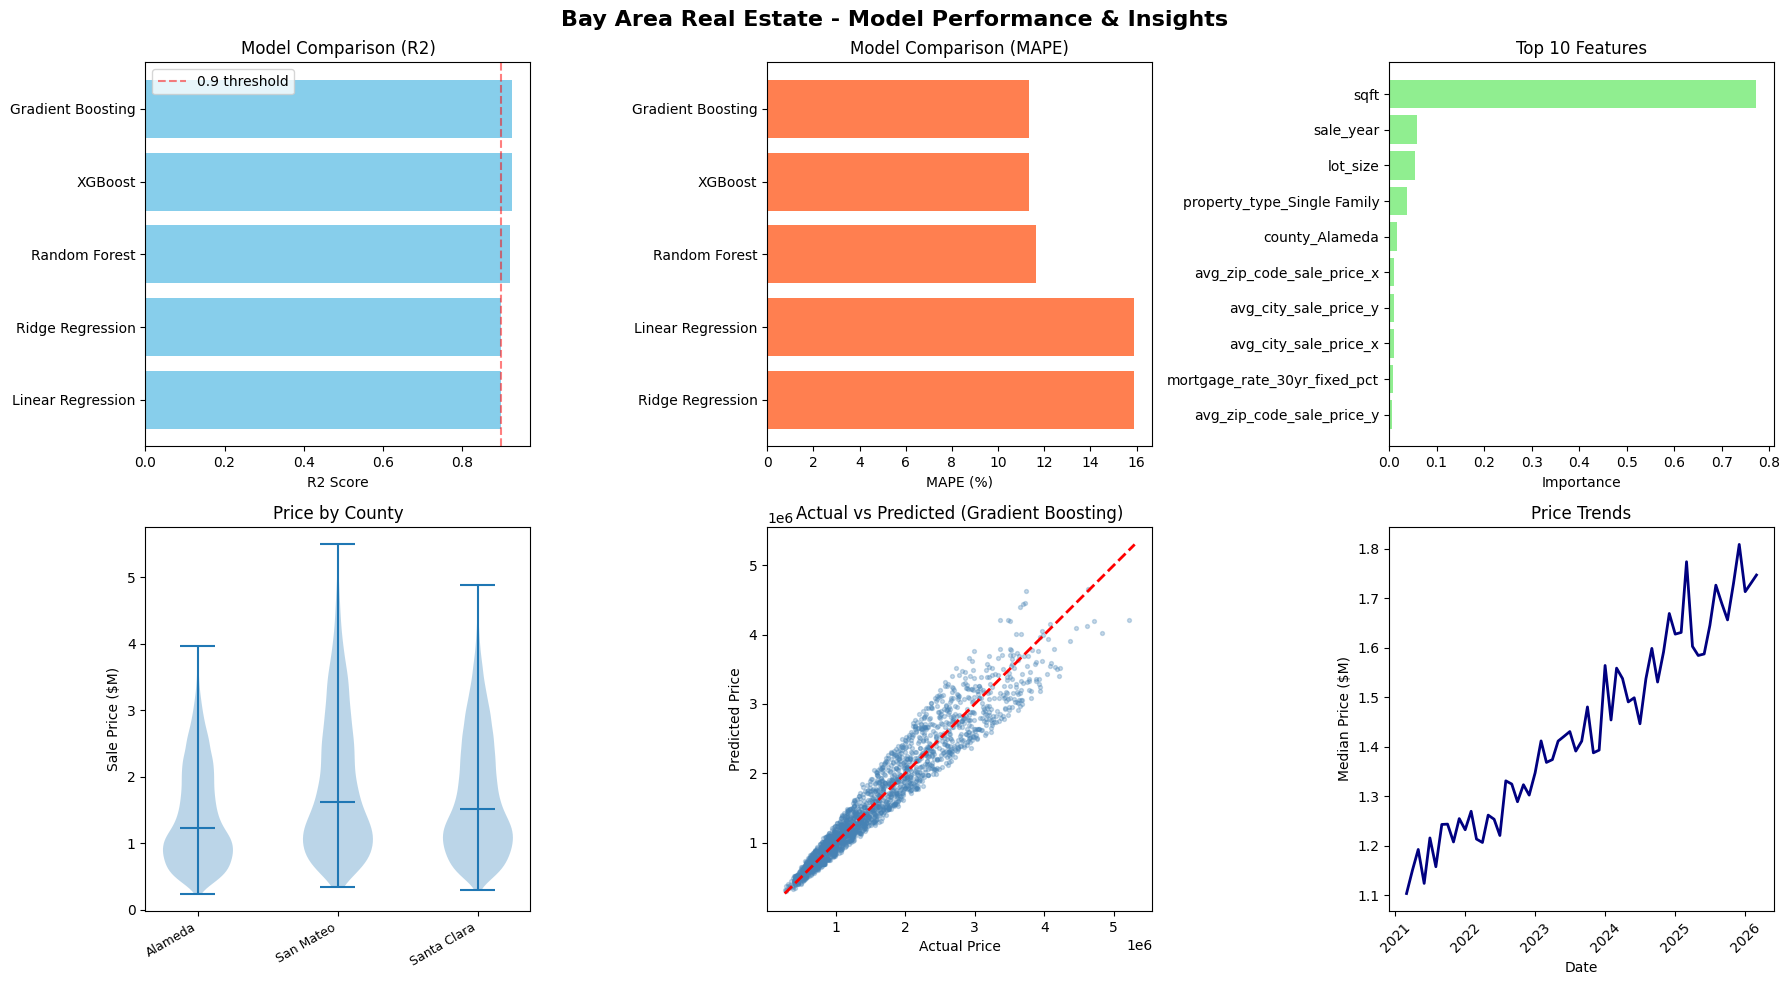

  Saved: results/model_performance.png


In [4]:
# ══════════════════════════════════════════════════════════════════
# BONUS: VISUALISATIONS - multi model comparison 
# ══════════════════════════════════════════════════════════════════
print("\n[BONUS] CREATING VISUALIZATIONS...")
os.makedirs('results', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Bay Area Real Estate - Model Performance & Insights',
             fontsize=16, fontweight='bold')

# 1. Model R2 Comparison
ax1 = axes[0, 0]
rs = results_df.sort_values('R2')
ax1.barh(rs['Model'], rs['R2'], color='skyblue')
ax1.set_xlabel('R2 Score')
ax1.set_title('Model Comparison (R2)')
ax1.axvline(x=0.9, color='r', linestyle='--', alpha=0.5, label='0.9 threshold')
ax1.legend()

# 2. MAPE Comparison
ax2 = axes[0, 1]
rs2 = results_df.sort_values('MAPE', ascending=False)
ax2.barh(rs2['Model'], rs2['MAPE'], color='coral')
ax2.set_xlabel('MAPE (%)')
ax2.set_title('Model Comparison (MAPE)')

# 3. Feature Importance
ax3 = axes[0, 2]
if importance is not None:
    top10 = importance.head(10).sort_values('importance')
    ax3.barh(top10['feature'], top10['importance'], color='lightgreen')
    ax3.set_xlabel('Importance')
    ax3.set_title('Top 10 Features')

# 4. Price by County (violin — faster than boxplot, no suptitle bug)
ax4 = axes[1, 0]
counties = sorted(df['county'].unique())
violin_data = [df.loc[df['county'] == c, 'sale_price'].values / 1e6 for c in counties]
ax4.violinplot(violin_data, positions=range(len(counties)), showmedians=True)
ax4.set_xticks(range(len(counties)))
ax4.set_xticklabels(counties, rotation=30, ha='right', fontsize=9)
ax4.set_ylabel('Sale Price ($M)')
ax4.set_title('Price by County')

# 5. Actual vs Predicted — SUBSAMPLED (fixes the 6-hour hang)
ax5 = axes[1, 1]
best_preds = {'Linear Regression': y_pred_lr, 'Ridge Regression': y_pred_ridge,
              'Random Forest': y_pred_rf, 'Gradient Boosting': y_pred_gb,
              'XGBoost': y_pred_xgb}
y_pred_best = best_preds.get(best_model_name, y_pred_rf)
n_plot = min(2000, len(y_test))
idx = np.random.RandomState(42).choice(len(y_test), n_plot, replace=False)
ax5.scatter(y_test.values[idx], y_pred_best[idx],
            alpha=0.3, s=8, rasterized=True, c='steelblue')
ax5.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax5.set_xlabel('Actual Price')
ax5.set_ylabel('Predicted Price')
ax5.set_title(f'Actual vs Predicted ({best_model_name})')

# 6. Price Trends — FIX: create monthly FIRST
ax6 = axes[1, 2]
monthly = (df.groupby(['sale_year', 'sale_month'])['sale_price']
           .median().reset_index())
monthly['date'] = pd.to_datetime(
    dict(year=monthly['sale_year'], month=monthly['sale_month'], day=1))
ax6.plot(monthly['date'], monthly['sale_price'] / 1e6, color='navy', lw=2)
ax6.set_xlabel('Date')
ax6.set_ylabel('Median Price ($M)')
ax6.set_title('Price Trends')
ax6.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('results/model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: results/model_performance.png")

  PREDICTION ACCURACY REPORT (Gradient Boosting)

  Test samples:         9,982

  ── Error Metrics ──
  R2 Score:             0.9274
  MAE:                  $182,706
  RMSE:                 $239,313
  MAPE:                 11.33%
  Median APE:           10.79%

  ── Accuracy Bands ──
  Within  5%:           2,300 / 9,982  (23.0%)
  Within 10%:           4,636 / 9,982  (46.4%)
  Within 15%:           6,963 / 9,982  (69.8%)
  Within 20%:           8,729 / 9,982  (87.4%)

  ── Bias Check ──
  Over-predicted:       5,028  (50.4%)
  Under-predicted:      4,954  (49.6%)
  Mean error:           $+958
  Median error:         $+1,825

  ── Accuracy by Price Range ──
  Range         Count          MAE     MAPE   Within 10%
  ────────────────────────────────────────────────────
  <500K           355 $    57,458    13.7%       37.5%
  500K-1M       2,495 $    92,100    12.0%       44.5%
  1M-1.5M       2,371 $   135,478    11.0%       48.8%
  1.5M-2M       1,547 $   203,681    11.7%       44.8%
 

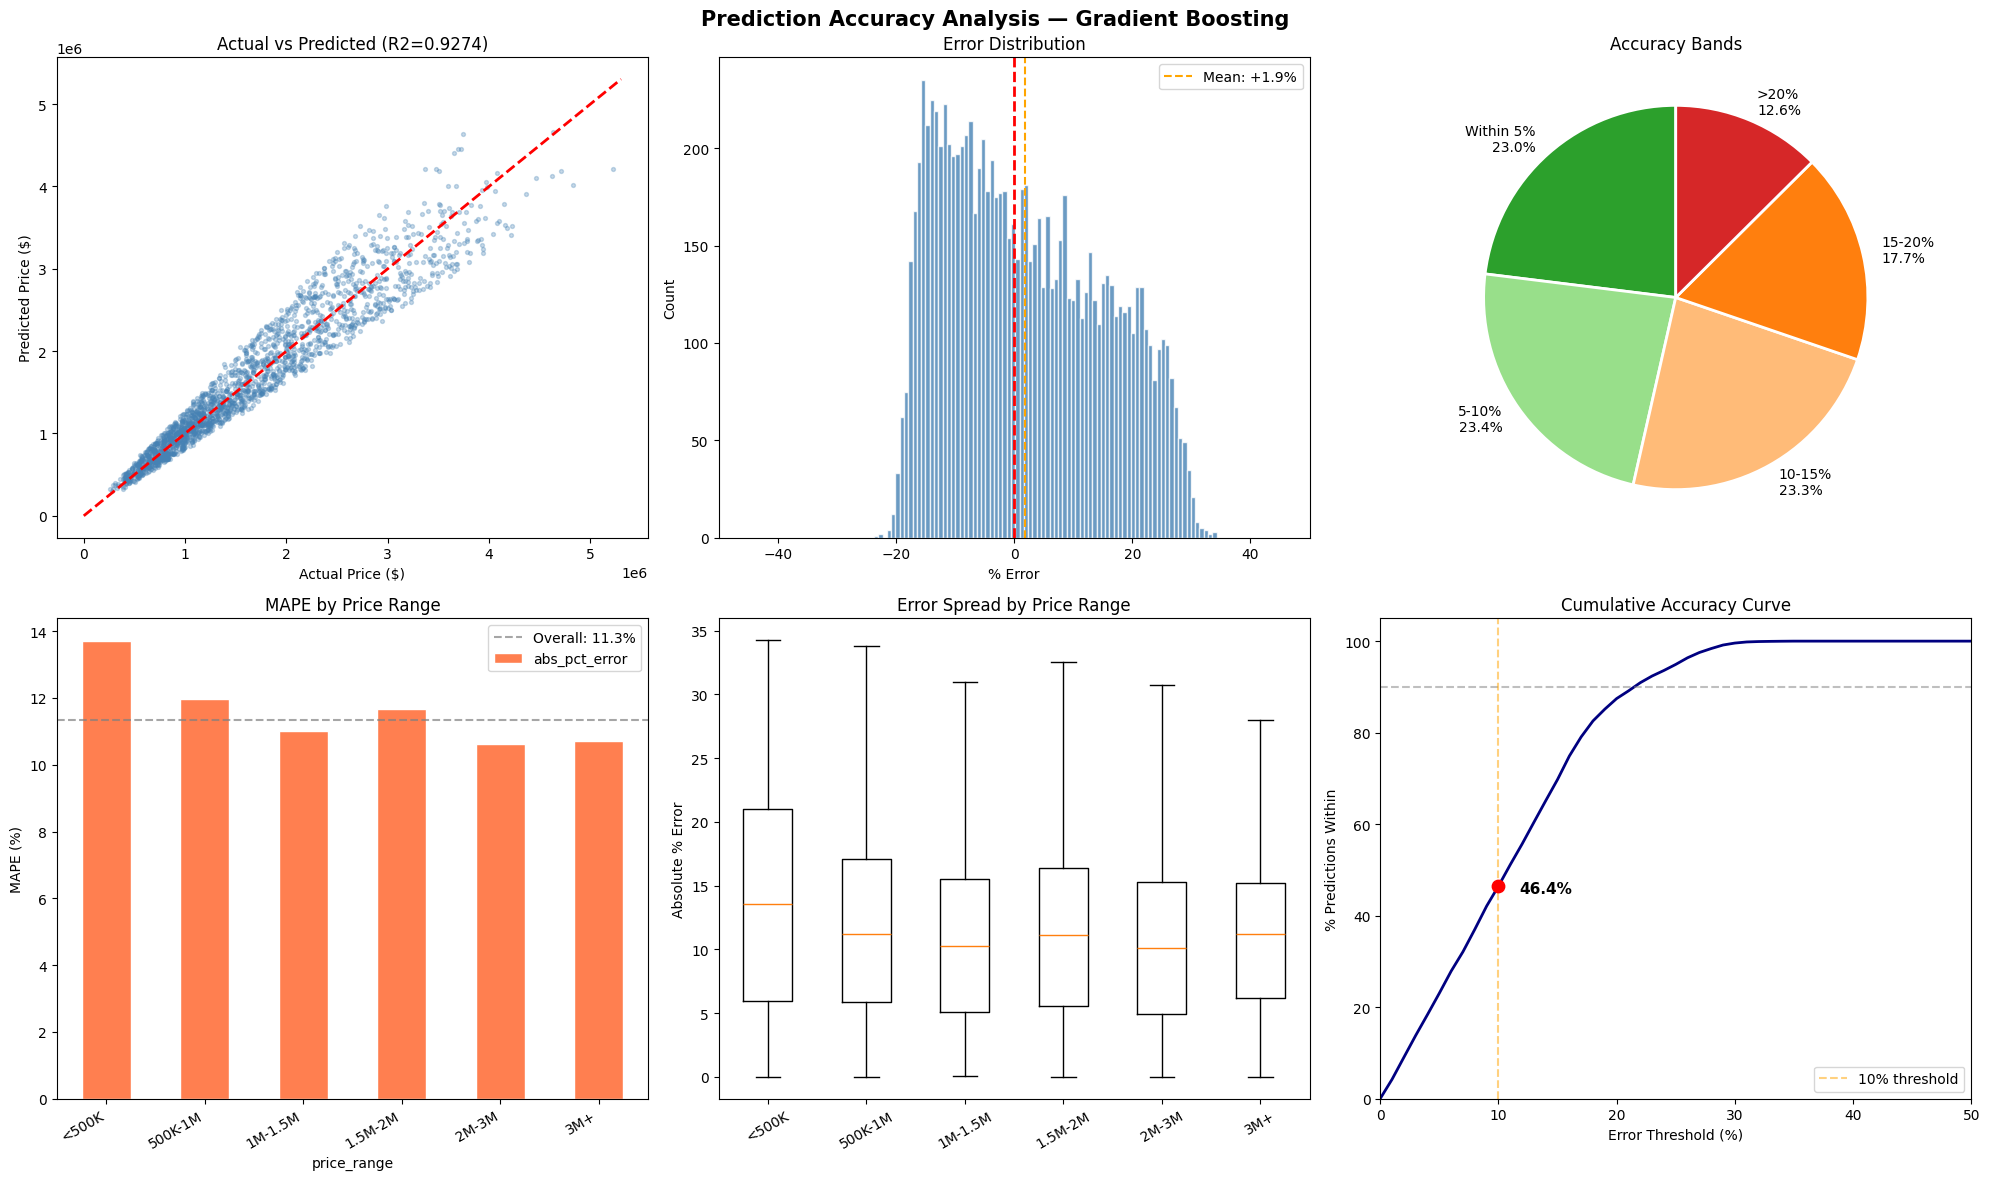

  Saved: results/prediction_accuracy.png
  Saved: results/test_predictions.csv (9,982 rows)


In [5]:
# ══════════════════════════════════════════════════════════════════
# TEST SET — Detailed Prediction Accuracy Analysis
# ════════════════════════════════════════════════════ ══════════════

test_results = X_test.copy()
test_results['actual_price']    = y_test.values
test_results['predicted_price'] = y_pred_best

# ── Error metrics per property ────────────────────────────────────
test_results['error']         = test_results['predicted_price'] - test_results['actual_price']
test_results['abs_error']     = test_results['error'].abs()
test_results['pct_error']     = (test_results['error'] / test_results['actual_price']) * 100
test_results['abs_pct_error'] = test_results['pct_error'].abs()
test_results['within_5pct']   = (test_results['abs_pct_error'] <= 5).astype(int)
test_results['within_10pct']  = (test_results['abs_pct_error'] <= 10).astype(int)
test_results['within_15pct']  = (test_results['abs_pct_error'] <= 15).astype(int)
test_results['within_20pct']  = (test_results['abs_pct_error'] <= 20).astype(int)
test_results['over_predicted'] = (test_results['error'] > 0).astype(int)

# ══════════════════════════════════════════════════════════════════
# 1. OVERALL METRICS
# ══════════════════════════════════════════════════════════════════
n = len(test_results)
mae   = test_results['abs_error'].mean()
rmse  = np.sqrt((test_results['error'] ** 2).mean())
mape  = test_results['abs_pct_error'].mean()
mdape = test_results['abs_pct_error'].median()
r2    = r2_score(test_results['actual_price'], test_results['predicted_price'])

print("=" * 60)
print(f"  PREDICTION ACCURACY REPORT ({best_model_name})")
print("=" * 60)
print(f"\n  Test samples:         {n:,}")
print(f"\n  ── Error Metrics ──")
print(f"  R2 Score:             {r2:.4f}")
print(f"  MAE:                  ${mae:,.0f}")
print(f"  RMSE:                 ${rmse:,.0f}")
print(f"  MAPE:                 {mape:.2f}%")
print(f"  Median APE:           {mdape:.2f}%")

print(f"\n  ── Accuracy Bands ──")
print(f"  Within  5%:           {test_results['within_5pct'].sum():>5,} / {n:,}  ({test_results['within_5pct'].mean()*100:.1f}%)")
print(f"  Within 10%:           {test_results['within_10pct'].sum():>5,} / {n:,}  ({test_results['within_10pct'].mean()*100:.1f}%)")
print(f"  Within 15%:           {test_results['within_15pct'].sum():>5,} / {n:,}  ({test_results['within_15pct'].mean()*100:.1f}%)")
print(f"  Within 20%:           {test_results['within_20pct'].sum():>5,} / {n:,}  ({test_results['within_20pct'].mean()*100:.1f}%)")

print(f"\n  ── Bias Check ──")
print(f"  Over-predicted:       {test_results['over_predicted'].sum():,}  ({test_results['over_predicted'].mean()*100:.1f}%)")
print(f"  Under-predicted:      {n - test_results['over_predicted'].sum():,}  ({(1-test_results['over_predicted'].mean())*100:.1f}%)")
print(f"  Mean error:           ${test_results['error'].mean():+,.0f}")
print(f"  Median error:         ${test_results['error'].median():+,.0f}")

# ══════════════════════════════════════════════════════════════════
# 2. ERROR BY PRICE RANGE
# ══════════════════════════════════════════════════════════════════
bins = [0, 500_000, 1_000_000, 1_500_000, 2_000_000, 3_000_000, np.inf]
labels = ['<500K', '500K-1M', '1M-1.5M', '1.5M-2M', '2M-3M', '3M+']
test_results['price_range'] = pd.cut(test_results['actual_price'], bins=bins, labels=labels)

print(f"\n  ── Accuracy by Price Range ──")
print(f"  {'Range':<12} {'Count':>6} {'MAE':>12} {'MAPE':>8} {'Within 10%':>12}")
print(f"  {'─'*52}")
for rng in labels:
    sub = test_results[test_results['price_range'] == rng]
    if len(sub) == 0:
        continue
    print(f"  {rng:<12} {len(sub):>6,} ${sub['abs_error'].mean():>10,.0f} "
          f"{sub['abs_pct_error'].mean():>7.1f}% "
          f"{sub['within_10pct'].mean()*100:>10.1f}%")

# ══════════════════════════════════════════════════════════════════
# 3. ERROR BY COUNTY
# ══════════════════════════════════════════════════════════════════
# Recover county from one-hot columns
county_cols = [c for c in test_results.columns if c.startswith('county_')]
if county_cols:
    test_results['county'] = 'Alameda'  # base category (drop_first=True)
    for col in county_cols:
        county_name = col.replace('county_', '')
        test_results.loc[test_results[col] == 1, 'county'] = county_name

    print(f"\n  ── Accuracy by County ──")
    print(f"  {'County':<16} {'Count':>6} {'MAE':>12} {'MAPE':>8} {'Within 10%':>12}")
    print(f"  {'─'*56}")
    for county in sorted(test_results['county'].unique()):
        sub = test_results[test_results['county'] == county]
        print(f"  {county:<16} {len(sub):>6,} ${sub['abs_error'].mean():>10,.0f} "
              f"{sub['abs_pct_error'].mean():>7.1f}% "
              f"{sub['within_10pct'].mean()*100:>10.1f}%")

# ══════════════════════════════════════════════════════════════════
# 4. WORST PREDICTIONS (sanity check)
# ══════════════════════════════════════════════════════════════════
print(f"\n  ── Top 10 Worst Predictions ──")
worst = test_results.nlargest(10, 'abs_pct_error')
print(f"  {'Actual':>12} {'Predicted':>12} {'Error%':>8} {'Range':<12}")
print(f"  {'─'*46}")
for _, row in worst.iterrows():
    print(f"  ${row['actual_price']:>10,.0f} ${row['predicted_price']:>10,.0f} "
          f"{row['pct_error']:>+7.1f}% {row['price_range']}")

# ══════════════════════════════════════════════════════════════════
# 5. VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f'Prediction Accuracy Analysis — {best_model_name}',
             fontsize=15, fontweight='bold')

# 5a. Actual vs Predicted
ax = axes[0, 0]
n_plot = min(2000, n)
idx = np.random.RandomState(42).choice(n, n_plot, replace=False)
ax.scatter(test_results['actual_price'].values[idx],
           test_results['predicted_price'].values[idx],
           alpha=0.3, s=8, rasterized=True, c='steelblue')
ax.plot([0, test_results['actual_price'].max()],
        [0, test_results['actual_price'].max()], 'r--', lw=2)
ax.set_xlabel('Actual Price ($)'); ax.set_ylabel('Predicted Price ($)')
ax.set_title(f'Actual vs Predicted (R2={r2:.4f})')

# 5b. Error distribution
ax = axes[0, 1]
ax.hist(test_results['pct_error'], bins=80, color='steelblue',
        edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', lw=2, ls='--')
ax.axvline(test_results['pct_error'].mean(), color='orange', lw=1.5,
           ls='--', label=f'Mean: {test_results["pct_error"].mean():+.1f}%')
ax.set_xlabel('% Error'); ax.set_ylabel('Count')
ax.set_title('Error Distribution'); ax.legend()
ax.set_xlim(-50, 50)

# 5c. Accuracy bands pie chart
ax = axes[0, 2]
bands = [
    test_results['within_5pct'].mean(),
    test_results['within_10pct'].mean() - test_results['within_5pct'].mean(),
    test_results['within_15pct'].mean() - test_results['within_10pct'].mean(),
    test_results['within_20pct'].mean() - test_results['within_15pct'].mean(),
    1 - test_results['within_20pct'].mean(),
]
band_labels = ['Within 5%', '5-10%', '10-15%', '15-20%', '>20%']
colors = ['#2ca02c', '#98df8a', '#ffbb78', '#ff7f0e', '#d62728']
ax.pie(bands, labels=[f'{l}\n{v*100:.1f}%' for l, v in zip(band_labels, bands)],
       colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Accuracy Bands')

# 5d. MAPE by price range
ax = axes[1, 0]
range_mape = test_results.groupby('price_range')['abs_pct_error'].mean()
range_mape.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_ylabel('MAPE (%)'); ax.set_title('MAPE by Price Range')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.axhline(mape, color='grey', ls='--', alpha=0.7, label=f'Overall: {mape:.1f}%')
ax.legend()

# 5e. Abs error by price range (box)
ax = axes[1, 1]
price_ranges = [labels[i] for i in range(len(labels))
                if labels[i] in test_results['price_range'].values]
box_data = [test_results.loc[test_results['price_range'] == r, 'abs_pct_error'].values
            for r in price_ranges]
ax.boxplot(box_data, labels=price_ranges, showfliers=False)
ax.set_ylabel('Absolute % Error'); ax.set_title('Error Spread by Price Range')
ax.tick_params(axis='x', rotation=30)

# 5f. Cumulative accuracy
ax = axes[1, 2]
thresholds = np.arange(0, 51, 1)
cum_acc = [(test_results['abs_pct_error'] <= t).mean() * 100 for t in thresholds]
ax.plot(thresholds, cum_acc, lw=2, color='navy')
ax.axhline(90, color='grey', ls='--', alpha=0.5)
ax.axvline(10, color='orange', ls='--', alpha=0.5, label='10% threshold')
pct_at_10 = (test_results['abs_pct_error'] <= 10).mean() * 100
ax.scatter([10], [pct_at_10], color='red', s=80, zorder=5)
ax.annotate(f'{pct_at_10:.1f}%', (10, pct_at_10), fontsize=11,
            xytext=(15, -5), textcoords='offset points', fontweight='bold')
ax.set_xlabel('Error Threshold (%)'); ax.set_ylabel('% Predictions Within')
ax.set_title('Cumulative Accuracy Curve'); ax.legend()
ax.set_xlim(0, 50); ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('results/prediction_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: results/prediction_accuracy.png")

# ══════════════════════════════════════════════════════════════════
# SAVE
# ══════════════════════════════════════════════════════════════════
test_results.to_csv('results/test_predictions.csv', index=False)
print(f"  Saved: results/test_predictions.csv ({len(test_results):,} rows)")

In [6]:
# ── Merge predictions back with ALL original df columns ───────────

# df.loc[X_test.index] gives us the original rows that were in the test set
test_results = df.loc[X_test.index].copy()

# Add predictions + error metrics
test_results['predicted_price'] = y_pred_best
test_results['error']           = test_results['predicted_price'] - test_results['sale_price']
test_results['abs_error']       = test_results['error'].abs()
test_results['pct_error']       = (test_results['error'] / test_results['sale_price']) * 100
test_results['abs_pct_error']   = test_results['pct_error'].abs()
test_results['within_5pct']     = (test_results['abs_pct_error'] <= 5).astype(int)
test_results['within_10pct']    = (test_results['abs_pct_error'] <= 10).astype(int)
test_results['within_15pct']    = (test_results['abs_pct_error'] <= 15).astype(int)
test_results['within_20pct']    = (test_results['abs_pct_error'] <= 20).astype(int)
test_results['over_predicted']  = (test_results['error'] > 0).astype(int)

# Save
test_results.to_csv('results/test_predictions_full.csv', index=False)

print(f"  Saved: results/test_predictions_full.csv")
print(f"  Rows:    {len(test_results):,}")
print(f"  Columns: {len(test_results.columns)}")
print(f"\n  Columns in file:")
print(f"  {test_results.columns.tolist()}")
print(f"\n  Preview:")
preview_cols = ['property_id', 'city', 'zip_code', 'bedrooms', 'bathrooms',
                'sqft', 'latitude', 'longitude', 'sale_price',
                'predicted_price', 'pct_error']
print(test_results[[c for c in preview_cols if c in test_results.columns]].head(10).to_string())

  Saved: results/test_predictions_full.csv
  Rows:    9,982
  Columns: 56

  Columns in file:
  ['property_id', 'county', 'city', 'zip_code', 'property_type', 'bedrooms', 'bathrooms', 'sqft', 'lot_size', 'year_built', 'sale_date', 'rate_week_ending', 'mortgage_rate_30yr_fixed_pct', 'sale_price', 'price_per_sqft', 'hoa_fee', 'latitude', 'longitude', 'parking_spaces', 'pool', 'fireplace', 'stories', 'sale_year', 'sale_month', 'sale_quarter', 'property_age', 'is_new_construction', 'bath_bed_ratio', 'sqft_per_bedroom', 'amenity_score', 'has_hoa', 'is_single_family', 'avg_zip_code_sale_price_x', 'avg_city_sale_price_x', 'n_parks', 'kid_friendly_score', 'Attractions', 'Restaurants', 'Things_to_do_score', 'resturant_score', 'walk_score', 'transit_score', 'bike_score', 'coolness_index', 'avg_zip_code_sale_price_y', 'avg_city_sale_price_y', 'predicted_price', 'error', 'abs_error', 'pct_error', 'abs_pct_error', 'within_5pct', 'within_10pct', 'within_15pct', 'within_20pct', 'over_predicted']

  P

In [9]:
# ── Pre-compute lookup dicts (run once after training) ────────────────────────
global_mean      = df['sale_price'].mean()
zip_avg_dict     = df.groupby('zip_code')['sale_price'].mean().to_dict()
city_avg_dict    = df.groupby('city')['sale_price'].mean().to_dict()

print(f"  Zip lookup:  {len(zip_avg_dict)} zips")
print(f"  City lookup: {len(city_avg_dict)} cities")




# ── Geocode cache (avoids duplicate API calls) ────────────────────────────────
# ── Imports ───────────────────────────────────────────────────────────────────
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from functools import lru_cache

# ── Initialize geolocator with rate limiter ───────────────────────────────────
geolocator  = Nominatim(user_agent="bay_area_property_predictor")
_geocode_rl = RateLimiter(geolocator.geocode, min_delay_seconds=1)

@lru_cache(maxsize=256)
def geocode_address(address):
    location = _geocode_rl(address)
    if location:
        return location.latitude, location.longitude
    print(f"  WARNING: Could not geocode '{address}', using Bay Area center")
    return 37.38, -122.0


# ── Predict function ──────────────────────────────────────────────────────────
def predict_price(address, sqft, bedrooms, bathrooms, lot_size,
                  year_built, property_type, county, city, zip_code,
                  pool=0, fireplace=0, parking_spaces=2, hoa_fee=0,
                  stories=1, latitude=None, longitude=None,
                  sale_year=2025, sale_month=6,
                  mortgage_rate_30yr_fixed_pct=6.8,
                  coolness_index=0,        # ← new parameter
                  kid_friendly_score=0,    # ← new parameter
                  model=best_model, train_cols=X_train.columns,
                  zip_avgs=zip_avg_dict, city_avgs=city_avg_dict,
                  zip_default=global_mean, city_default=global_mean):
    """
    Predict sale price given an address + property details.
    Auto-geocodes the address for latitude/longitude if not provided.
    Includes ALL features from training data.
    """
    # ── 1. Geocode address → lat/lon ──────────────────────────────────────────
    if latitude is None or longitude is None:
        latitude, longitude = geocode_address(address)

    # ── 2. Normalize zip_code type ────────────────────────────────────────────
    zip_code = int(zip_code)

    # ── 3. Build row with ALL training features ───────────────────────────────
    row = {
        # Raw property features
        'bedrooms':                    bedrooms,
        'bathrooms':                   bathrooms,
        'sqft':                        sqft,
        'lot_size':                    lot_size,
        'hoa_fee':                     hoa_fee,
        'parking_spaces':              parking_spaces,
        'pool':                        pool,
        'fireplace':                   fireplace,
        'stories':                     stories,
        'latitude':                    latitude,
        'longitude':                   longitude,
        'coolness_index':              coolness_index,
        'kid_friendly_score':          kid_friendly_score,

        # Mortgage rate
        'mortgage_rate_30yr_fixed_pct': mortgage_rate_30yr_fixed_pct,

        # Time features
        'sale_year':                   sale_year,
        'sale_month':                  sale_month,
        'sale_quarter':                (sale_month - 1) // 3 + 1,

        # Engineered features
        'property_age':                sale_year - year_built,
        'is_new_construction':         int((sale_year - year_built) <= 5),
        'bath_bed_ratio':              bathrooms / (bedrooms + 1),
        'sqft_per_bedroom':            sqft / (bedrooms + 1),
        'amenity_score':               pool + fireplace + parking_spaces,
        'has_hoa':                     int(hoa_fee > 0),

        # Target-encoded location features
        'avg_zip_code_sale_price':     zip_avgs.get(zip_code, zip_default),
        'avg_city_sale_price':         city_avgs.get(city, city_default),

        # Categoricals (will be one-hot encoded below)
        'property_type':               property_type,
        'county':                      county,
        'city':                        city,
    }

    # ── 4. One-hot encode categoricals ────────────────────────────────────────
    row_df      = pd.DataFrame([row])
    cat_cols    = ['property_type', 'county', 'city']
    row_encoded = pd.get_dummies(
        row_df, columns=[c for c in cat_cols if c in row_df.columns],
        drop_first=False)

    # ── 5. Align with training columns (missing dummies = 0) ─────────────────
    row_aligned = row_encoded.reindex(columns=train_cols, fill_value=False)
    row_aligned = row_aligned.select_dtypes(include=['number', 'bool']).fillna(0)
    display(row_aligned)

    # ── 6. Sanity check: flag missing features ────────────────────────────────
    missing = set(train_cols) - set(row_aligned.columns)
    if missing:
        print(f"  WARNING: Missing features (filled with 0): {missing}")

    # ── 7. Predict ────────────────────────────────────────────────────────────
    price    = model.predict(row_aligned)[0]
    zip_avg  = zip_avgs.get(zip_code, zip_default)
    city_avg = city_avgs.get(city, city_default)

    # ── 8. Print summary ──────────────────────────────────────────────────────
    print(f"\n  {'='*55}")
    print(f"  Address:    {address}")
    print(f"  Lat/Lon:    {latitude:.4f}, {longitude:.4f}")
    print(f"  Zip:        {zip_code}  (avg ${zip_avg:,.0f})")
    print(f"  City:       {city}  (avg ${city_avg:,.0f})")
    print(f"  County:     {county}")
    print(f"  Type:       {property_type}")
    print(f"  Specs:      {bedrooms}bd / {bathrooms}ba / {sqft:,} sqft / "
          f"{lot_size:,} lot / {stories} story")
    print(f"  Age:        {sale_year - year_built} yrs (built {year_built})")
    print(f"  Amenities:  pool={pool}  fireplace={fireplace}  "
          f"parking={parking_spaces}  HOA=${hoa_fee:,}")
    print(f"  Scores:     coolness={coolness_index}  kid_friendly={kid_friendly_score}")
    print(f"  Rate:       {mortgage_rate_30yr_fixed_pct}%")
    print(f"  {'─'*55}")
    print(f"  Predicted:  ${price:,.0f}")
    print(f"  $/sqft:     ${price/sqft:,.0f}")
    print(f"  {'='*55}\n")

    return price


# ── Tests ─────────────────────────────────────────────────────────────────────
import time

test_cases = [
    ("1582 Petal Way, San Jose, CA 95129",
     dict(sqft=1476, bedrooms=3, bathrooms=2, lot_size=5998,
          year_built=1960, property_type="Single Family",
          county="Santa Clara", city="San Jose", zip_code=95129,
          coolness_index=72, kid_friendly_score=85,
          stories=1, pool=0, fireplace=1, parking_spaces=2, hoa_fee=0)),

    ("2000 Webster St, Palo Alto, CA 94301",
     dict(sqft=1800, bedrooms=3, bathrooms=2, lot_size=6500,
          year_built=1955, property_type="Single Family",
          county="Santa Clara", city="Palo Alto", zip_code=94301,
          coolness_index=90, kid_friendly_score=78,
          stories=2, pool=0, fireplace=1, parking_spaces=2, hoa_fee=0)),

    ("500 E Santa Clara St, San Jose, CA 95112",
     dict(sqft=1200, bedrooms=2, bathrooms=1, lot_size=4000,
          year_built=1970, property_type="Single Family",
          county="Santa Clara", city="San Jose", zip_code=95112,
          coolness_index=65, kid_friendly_score=70,
          stories=1, pool=0, fireplace=0, parking_spaces=1, hoa_fee=0)),
]

for address, kwargs in test_cases:
    predict_price(address, **kwargs)
    time.sleep(1)

  Zip lookup:  143 zips
  City lookup: 44 cities


,bedrooms,bathrooms,sqft,lot_size,mortgage_rate_30yr_fixed_pct,hoa_fee,parking_spaces,pool,fireplace,stories,...,city_San Bruno,city_San Carlos,city_San Jose,city_San Leandro,city_San Mateo,city_Santa Clara,city_Saratoga,city_South San Francisco,city_Sunnyvale,city_Union City
0,3,2,1476,5998,6.8,0,2,0,1,1,...,False,False,True,False,False,False,False,False,False,False



  Address:    1582 Petal Way, San Jose, CA 95129
  Lat/Lon:    37.2952, -122.0121
  Zip:        95129  (avg $1,800,668)
  City:       San Jose  (avg $1,726,274)
  County:     Santa Clara
  Type:       Single Family
  Specs:      3bd / 2ba / 1,476 sqft / 5,998 lot / 1 story
  Age:        65 yrs (built 1960)
  Amenities:  pool=0  fireplace=1  parking=2  HOA=$0
  Scores:     coolness=72  kid_friendly=85
  Rate:       6.8%
  ───────────────────────────────────────────────────────
  Predicted:  $1,449,039
  $/sqft:     $982



,bedrooms,bathrooms,sqft,lot_size,mortgage_rate_30yr_fixed_pct,hoa_fee,parking_spaces,pool,fireplace,stories,...,city_San Bruno,city_San Carlos,city_San Jose,city_San Leandro,city_San Mateo,city_Santa Clara,city_Saratoga,city_South San Francisco,city_Sunnyvale,city_Union City
0,3,2,1800,6500,6.8,0,2,0,1,2,...,False,False,False,False,False,False,False,False,False,False



  Address:    2000 Webster St, Palo Alto, CA 94301
  Lat/Lon:    37.4376, -122.1395
  Zip:        94301  (avg $1,766,862)
  City:       Palo Alto  (avg $1,744,272)
  County:     Santa Clara
  Type:       Single Family
  Specs:      3bd / 2ba / 1,800 sqft / 6,500 lot / 2 story
  Age:        70 yrs (built 1955)
  Amenities:  pool=0  fireplace=1  parking=2  HOA=$0
  Scores:     coolness=90  kid_friendly=78
  Rate:       6.8%
  ───────────────────────────────────────────────────────
  Predicted:  $1,756,834
  $/sqft:     $976



,bedrooms,bathrooms,sqft,lot_size,mortgage_rate_30yr_fixed_pct,hoa_fee,parking_spaces,pool,fireplace,stories,...,city_San Bruno,city_San Carlos,city_San Jose,city_San Leandro,city_San Mateo,city_Santa Clara,city_Saratoga,city_South San Francisco,city_Sunnyvale,city_Union City
0,2,1,1200,4000,6.8,0,1,0,0,1,...,False,False,True,False,False,False,False,False,False,False



  Address:    500 E Santa Clara St, San Jose, CA 95112
  Lat/Lon:    37.3412, -121.8798
  Zip:        95112  (avg $1,764,454)
  City:       San Jose  (avg $1,726,274)
  County:     Santa Clara
  Type:       Single Family
  Specs:      2bd / 1ba / 1,200 sqft / 4,000 lot / 1 story
  Age:        55 yrs (built 1970)
  Amenities:  pool=0  fireplace=0  parking=1  HOA=$0
  Scores:     coolness=65  kid_friendly=70
  Rate:       6.8%
  ───────────────────────────────────────────────────────
  Predicted:  $1,237,535
  $/sqft:     $1,031

